# Testing STAGED on Rotation Simulator

This notebook loads the `RotationData` h5ad file, converts it into the
dict format expected by STAGED, constructs a `Config`, trains the model,
and plots the training-loss curve along with a qualitative prediction
comparison.

In [1]:
# --- stdlib / third-party imports ---
import sys
import os

import numpy as np
import torch
import anndata
import networkx as nx
import matplotlib.pyplot as plt
from tqdm import tqdm

# Add src to path so we can import STAGED modules
sys.path.insert(0, os.path.join("..", "..", "src"))

from config.config import Config, DataConfig, ModelConfig, TrainingConfig, SystemConfig, LoggingConfig, InferenceConfig
from models.staged import STAGED
from data.data_processor import DataProcessor
from trainer.trainer import STAGEDTrainer

## 1 · Load the h5ad file produced by `RotationData.save()`

In [2]:
H5AD_PATH = os.path.join("..", "..", "simdata", "rotation_data.h5ad")   # adjust if the file lives elsewhere

adata = anndata.read_h5ad(H5AD_PATH)
print(adata)
print("\nKeys in adata.uns:", list(adata.uns.keys()))
print("adata.obs columns:  ", list(adata.obs.columns))
print("adata.var columns:  ", list(adata.var.columns))

AnnData object with n_obs × n_vars = 100 × 100
    obs: 'cell_idx', 'cell_type', 'grid_row', 'grid_col'
    var: 'coord_idx', 'owning_type'
    uns: 'ligand_receptors', 'map', 'params', 'pos'
    obsm: 'X_spatial'

Keys in adata.uns: ['ligand_receptors', 'map', 'params', 'pos']
adata.obs columns:   ['cell_idx', 'cell_type', 'grid_row', 'grid_col']
adata.var columns:   ['coord_idx', 'owning_type']


## 2 · Inspect the simulation parameters stored in the file

In [3]:
params = adata.uns["params"]
print("Simulation parameters:")
for k, v in params.items():
    print(f"  {k}: {v}")

n_types          = int(params["n_types"])
n_cells          = adata.n_obs
dim              = adata.n_vars                  # = params["dim"]
nt               = int(params["nt"])

Simulation parameters:
  dim: 100
  n_cols: 10
  n_ligand_receptors: 2
  n_rows: 10
  n_types: 3
  nt: 100
  theta: 0.17771531752633465


## 3 · Convert h5ad → STAGED data dict

STAGED expects a dict with the following keys:

| key | shape / type | description |
|---|---|---|
| `gene_expression` | `(T, C, G)` float32 tensor | expression at every timestep |
| `cell_positions`  | `(T, C, 2)` float32 tensor | spatial positions (constant here) |
| `genes`           | `List[str]` | gene / coordinate names |
| `cell_type_assignments` | `(C,)` long tensor | integer cell-type per cell |
| `prior_grns`      | `Dict[int, nx.DiGraph]` | one GRN per cell type |
| `ligand_receptor_pairs` | `List[(str,str)]` | (ligand gene, receptor gene) |
| `receptor_gene_pairs`   | `List[(str,str)]` | (receptor gene, target gene) |
| `n_time_points`, `n_cells`, `n_genes` | int | dimensions |

In [4]:
# --- gene expression: full trajectory stored in adata.uns["pos"] ---
# pos has shape (T, C, dim); each cell only "sees" its own type block,
# so we replicate the zero-masking that save() applies to adata.X.
pos = adata.uns["pos"]                           # (T, C, dim)  numpy float64

# Rebuild the type-block mask so non-owned coords stay zero every timestep
cell_types_arr = adata.obs["cell_type"].cat.codes.values   # (C,) int
owning_type    = adata.var["owning_type"].values           # (dim,) int

# Mask: for each cell, only keep coords whose owning_type == that cell's type
mask = (owning_type[None, :] == cell_types_arr[:, None])  # (C, dim)  bool

# Apply mask across time: (T, C, dim)
gene_expr_np = pos * mask[None, :, :]             # broadcast over T
gene_expression = torch.tensor(gene_expr_np, dtype=torch.float32)

print("gene_expression shape:", gene_expression.shape)   # (T, C, dim)

# --- cell positions: time-invariant 2D grid ---
# adata.obsm["X_spatial"] is (C, 2); broadcast to (T, C, 2)
spatial_2d      = adata.obsm["X_spatial"].astype(np.float32)   # (C, 2)
cell_positions  = torch.tensor(
    np.broadcast_to(spatial_2d[None], (nt, n_cells, 2)).copy(),
    dtype=torch.float32
)
print("cell_positions shape:", cell_positions.shape)

# --- gene / coordinate names ---
genes = adata.var_names.tolist()           # ["coord_0", "coord_1", …]
print(f"Number of genes (coordinates): {len(genes)}")

# --- cell-type assignments ---
cell_type_assignments = torch.tensor(cell_types_arr, dtype=torch.long)
print("cell_type_assignments:", cell_type_assignments.shape,
      "unique types:", cell_type_assignments.unique().tolist())

gene_expression shape: torch.Size([100, 100, 100])
cell_positions shape: torch.Size([100, 100, 2])
Number of genes (coordinates): 100
cell_type_assignments: torch.Size([100]) unique types: [0, 1, 2]


### 3a · Build prior GRNs from the simulation's type blocks

For each cell type we construct a ring-graph over that type's coordinate
block — matching the `internal_connections` structure used inside
`RotationData`.  This is a reasonable choice because the rotation mixes
coordinates within each type block via exactly those ring edges.

In [5]:
# Recover per-type coordinate lists from adata.var
type_dims = {
    t: adata.var.index[owning_type == t].tolist()
    for t in range(n_types)
}

prior_grns: dict[int, nx.DiGraph] = {}
for t, coords in type_dims.items():
    g = nx.DiGraph()
    g.add_nodes_from(genes)           # all coord names as nodes
    n = len(coords)
    for k in range(n):
        src = coords[k]
        dst = coords[(k + 1) % n]
        g.add_edge(src, dst)          # ring edges within the type block
    prior_grns[t] = g
    print(f"  Type {t}: {len(coords)} coords, {g.number_of_edges()} GRN edges")

  Type 0: 34 coords, 34 GRN edges
  Type 1: 33 coords, 33 GRN edges
  Type 2: 33 coords, 33 GRN edges


### 3b · Build ligand-receptor and receptor-gene pairs

The simulator stores cross-type Givens rotation pairs as ligand-receptor
interactions.  Each entry has `ligand_coord` (source type's block) and
`receptor_coord` (target type's block); both are integer indices into the
dim-dimensional state vector which correspond to `coord_<i>` gene names.

In [6]:
lr_data = adata.uns["ligand_receptors"]

ligand_receptor_pairs: list[tuple[str, str]] = []
receptor_gene_pairs:   list[tuple[str, str]] = []

seen_lr  = set()
seen_rg  = set()

for src_t, tgt_t, lig_i, rec_i in zip(
    lr_data["source_type"],
    lr_data["target_type"],
    lr_data["ligand_coord"],
    lr_data["receptor_coord"],
):
    lig_name = f"coord_{lig_i}"
    rec_name = f"coord_{rec_i}"

    lr_pair = (lig_name, rec_name)
    if lr_pair not in seen_lr:
        ligand_receptor_pairs.append(lr_pair)
        seen_lr.add(lr_pair)

    # Receptor → downstream genes: all coords in the target type's block
    for tgt_gene in type_dims[int(tgt_t)]:
        rg_pair = (rec_name, tgt_gene)
        if rg_pair not in seen_rg:
            receptor_gene_pairs.append(rg_pair)
            seen_rg.add(rg_pair)

print(f"Ligand-receptor pairs : {len(ligand_receptor_pairs)}")
print(f"Receptor-gene pairs   : {len(receptor_gene_pairs)}")

Ligand-receptor pairs : 8
Receptor-gene pairs   : 266


### 3c · Validate & filter pairs against the gene list

In [7]:
valid_genes = set(genes)

ligand_receptor_pairs = [
    (l, r) for l, r in ligand_receptor_pairs if l in valid_genes and r in valid_genes
]
receptor_gene_pairs = [
    (r, g) for r, g in receptor_gene_pairs if r in valid_genes and g in valid_genes
]

print(f"After validation — LR pairs: {len(ligand_receptor_pairs)}, RG pairs: {len(receptor_gene_pairs)}")

After validation — LR pairs: 8, RG pairs: 266


### 3d · Assemble the final data dict

In [8]:
data = {
    "gene_expression":       gene_expression,
    "cell_positions":        cell_positions,
    "genes":                 genes,
    "cell_type_assignments": cell_type_assignments,
    "prior_grns":            prior_grns,
    "ligand_receptor_pairs": ligand_receptor_pairs,
    "receptor_gene_pairs":   receptor_gene_pairs,
    "n_time_points":         gene_expression.shape[0],
    "n_cells":               gene_expression.shape[1],
    "n_genes":               gene_expression.shape[2],
}

print("Data dict keys:", list(data.keys()))
print(f"  n_time_points : {data['n_time_points']}")
print(f"  n_cells       : {data['n_cells']}")
print(f"  n_genes       : {data['n_genes']}")

Data dict keys: ['gene_expression', 'cell_positions', 'genes', 'cell_type_assignments', 'prior_grns', 'ligand_receptor_pairs', 'receptor_gene_pairs', 'n_time_points', 'n_cells', 'n_genes']
  n_time_points : 100
  n_cells       : 100
  n_genes       : 100


## 4 · Build a STAGED `Config`

We keep model dimensions small so the notebook runs quickly.  Increase
`hidden_dim`, `max_iterations`, or `time_points_per_iter` for a fuller run.

In [9]:
device_str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device_str}")

config = Config(
    data=DataConfig(
        data_type="rotation",          # informational only here
        distance_threshold=1.3,        # grid spacing is 1, so 1.3 catches 4-connected neighbors
    ),
    model=ModelConfig(
        hidden_dim=32,
        num_gat_layers=1,              # must be 1 for ODE mode
        num_mlp_layers=3,
        dropout=0.1,
        delta_gl=1,
        delta_lr=2,
        delta_rg=1,
        delta_gg=0,                    # 0 for ODE mode
        add_self_loops=True,
    ),
    training=TrainingConfig(
        prediction_mode="ode",
        max_iterations=30,             # increase for a longer training run
        batch_size=4,
        learning_rate=1e-3,
        weight_decay=1e-5,
        ode_method="rk4",
        time_points_per_iter=15,        # subsample T timepoints per gradient step
    ),
    system=SystemConfig(
        device=device_str,
        seed=42,
        output_dir="results/rotation",
    ),
    logging=LoggingConfig(level="INFO"),
    inference=InferenceConfig(store_attention=True, output_dir="results/rotation"),
)

Using device: cpu


## 5 · Initialise and train `STAGEDTrainer`

In [10]:
torch.manual_seed(config.system.seed)

trainer = STAGEDTrainer(
    data=data,
    genes=data["genes"],
    ligand_receptor_pairs=data["ligand_receptor_pairs"],
    receptor_gene_pairs=data["receptor_gene_pairs"],
    cell_type_assignments=data["cell_type_assignments"],
    prior_grns=data["prior_grns"],
    config=config,
)

print(f"\nModel has {sum(p.numel() for p in trainer.model.parameters()):,} trainable parameters")
print(f"Minimum warmup timestep (t_init): {trainer.model.get_t_init()}")
print(f"Training will use timesteps {trainer.min_time} … {data['n_time_points'] - 1}")

DataProcessor initialized with 100 genes

Model has 2,273 trainable parameters
Minimum warmup timestep (t_init): 2
Training will use timesteps 2 … 99


In [11]:
training_output = trainer.fit()
print(f"\nBest checkpoint saved to: {training_output.best_model_path}")

Training:   0%|                                                                                                                          | 0/30 [00:00<?, ?it/s]

  timepoints:   0%|                                                                                                                      | 0/15 [00:00<?, ?it/s]

  timepoints:   7%|███████▎                                                                                                      | 1/15 [00:01<00:18,  1.31s/it]

  timepoints:  13%|██████████████▋                                                                                               | 2/15 [00:02<00:16,  1.25s/it]

  timepoints:  20%|██████████████████████                                                                                        | 3/15 [00:03<00:14,  1.23s/it]

...

  timepoints: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:20<00:00,  1.29s/it]

Training:  97%|██████████████████████████████████████████████████████████████████████████████████████████████▋   | 29/30 [18:05<00:36, 36.48s/it, loss=0.001404]

Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [18:05<00:00, 36.40s/it, loss=0.001404]

Training: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 30/30 [18:05<00:00, 36.20s/it, loss=0.001404]


Best checkpoint saved to: results/rotation/checkpoints/checkpoints_20260525_133549/best_model.pt


## 6 · Training-loss curve

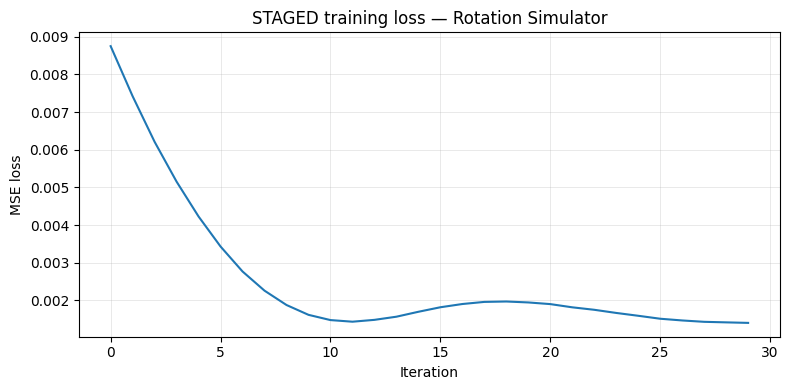

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(training_output.loss_history, linewidth=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE loss")
ax.set_title("STAGED training loss — Rotation Simulator")
ax.grid(True, linewidth=0.4, alpha=0.5)
fig.tight_layout()
plt.savefig("results/rotation/training_loss.png", dpi=150)
plt.show()

## 7 · Qualitative prediction check
Now, we will sample from cell trajectories, and see how well STAGED was able to predict them.

In [13]:
# how many plots to make
n_plots = 5
n_steps = 20
initial_time = 4

# determine which cells and which genes we will track over time
cells_to_check = np.random.choice(n_cells, n_plots, replace = False)
genes_to_check = []
for cell_idx in cells_to_check:
    cell_type = cell_types_arr[cell_idx]
    owned_indices = np.where(owning_type == cell_type)[0]
    genes_to_check.append(np.random.choice(owned_indices, 1)[0])

# get a predictor
from trainer.predictor import STAGEDPredictor
predictor = STAGEDPredictor(data = data, genes = genes, ligand_receptor_pairs = ligand_receptor_pairs, 
                            receptor_gene_pairs = receptor_gene_pairs, cell_type_assignments = cell_type_assignments,
                            prior_grns = prior_grns, autoregressive = True, config = config, checkpoint_path = training_output.best_model_path)

inference_output = predictor.inference(initial_time = initial_time, prediction_steps = n_steps, store_attention = False)

Loaded model weights from results/rotation/checkpoints/checkpoints_20260525_133549/best_model.pt
DataProcessor initialized with 100 genes


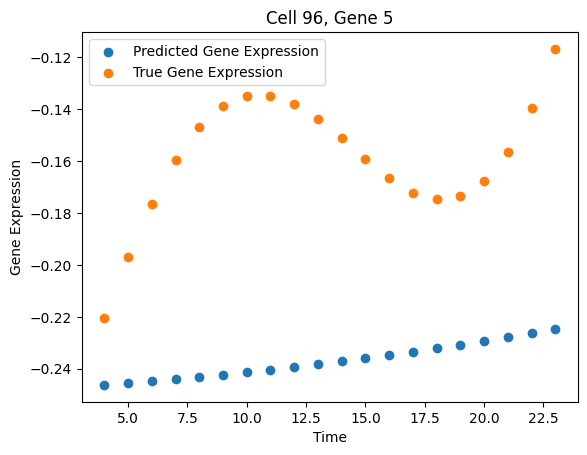

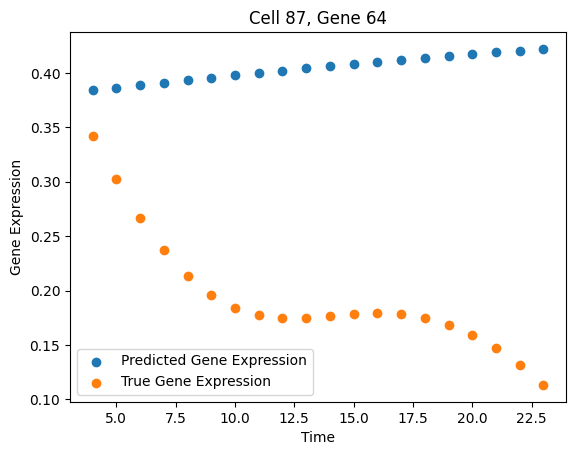

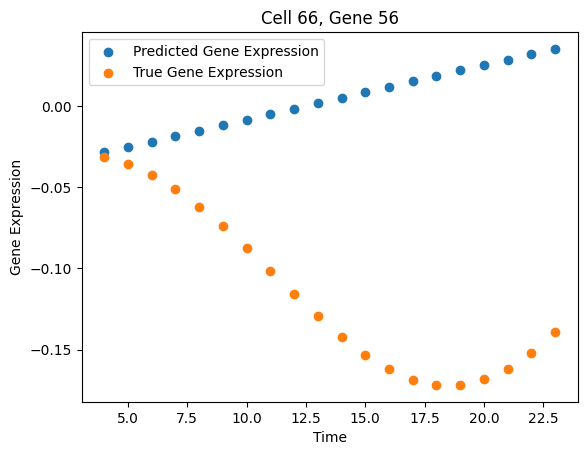

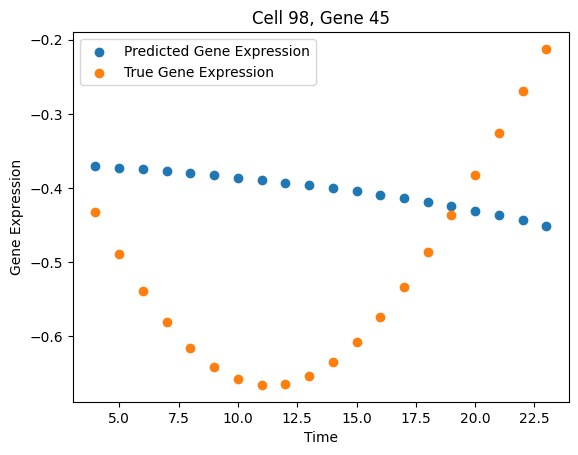

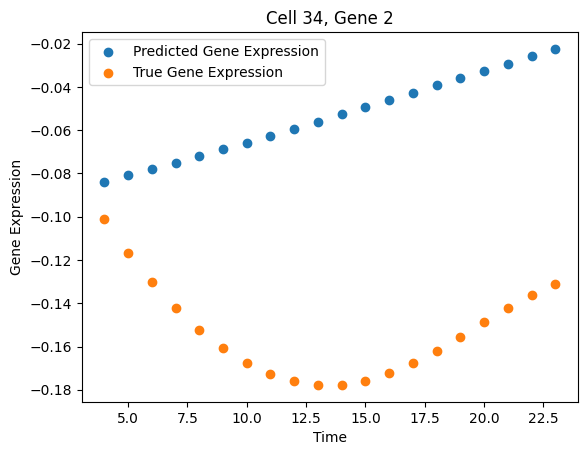

In [14]:
predicted_trajectories = inference_output.predictions
true_trajectories = trainer.processed_data.gene_expression[initial_time + 1 : initial_time + n_steps + 1]
predicted_trajectories.shape, true_trajectories.shape

# subset these to only show the selected genes
for plot_idx in range(n_plots):
    true = true_trajectories[:, cells_to_check[plot_idx], genes_to_check[plot_idx]].detach().cpu()
    pred = predicted_trajectories[:, cells_to_check[plot_idx], genes_to_check[plot_idx]].detach().cpu()
    time = np.arange(initial_time, initial_time + n_steps)
    plt.scatter(time, pred, label = 'Predicted Gene Expression')
    plt.scatter(time, true, label = 'True Gene Expression')
    plt.xlabel('Time')
    plt.ylabel('Gene Expression')
    plt.legend()
    plt.title(f'Cell {cells_to_check[plot_idx]}, Gene {genes_to_check[plot_idx]}')
    plt.show()